# Maina Faith Njeri-S13/02960/23
# Titanic Survival Prediction
## AI Assignment 2

# Part 1: Data Cleaning

This section focuses on preparing the Titanic dataset for analysis by handling missing values,
detecting and treating outliers, and ensuring data consistency.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

## Load Dataset

The dataset is loaded using pandas to inspect its structure.

In [5]:
df = pd.read_csv("../data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview
We inspect the structure of the dataset including column types and missing values.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Value Analysis
We check which columns contain missing values.

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Missing Value Analysis

The dataset contains missing values in the following columns:

Age – several passengers have missing ages  
Cabin – most values are missing  
Embarked – a few missing values

Different strategies were applied depending on the amount of missing data.

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Age values were imputed using the median because age distribution may contain
outliers and the median is more robust than the mean.

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Embarked is a categorical column. Missing values were replaced using the mode.

In [11]:
df['Cabin'] = df['Cabin'].fillna('U')

Cabin column had many missing values. Instead of dropping it, missing values were filled with 'U' so that Deck information could still be extracted later during feature engineering.

## Outlier Detection
We detect outliers in Age and Fare using boxplots.

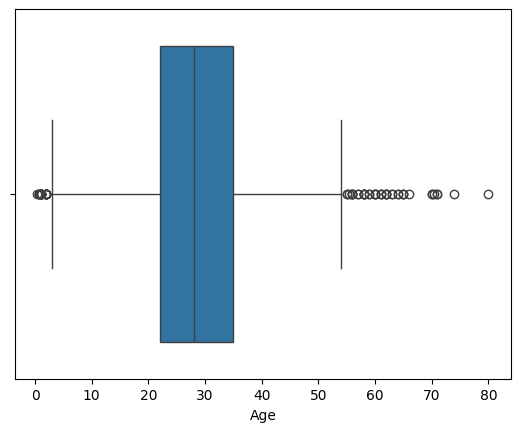

In [12]:
sns.boxplot(x=df['Age'])
plt.show()

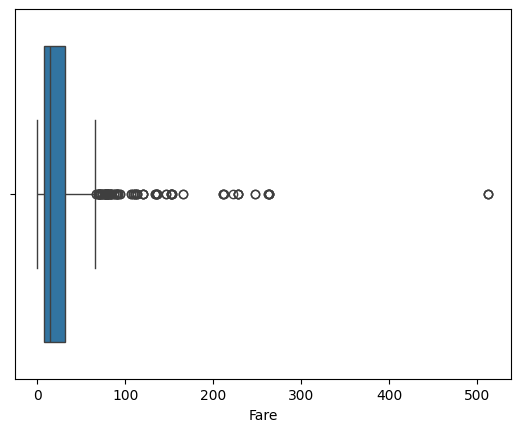

In [13]:
sns.boxplot(x=df['Fare'])
plt.show()

### Outlier Handling
Outliers in Fare are capped using the IQR method.

In [14]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Fare'] = np.where(df['Fare'] > upper, upper, df['Fare'])

Outliers were detected using boxplots. Extreme Fare values were capped
at the 99th percentile to reduce the influence of unusually high ticket prices.

## Data Consistency
We verify categorical variables and remove duplicates.

In [21]:
train.shape

(891, 12)

In [16]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
train = df.drop_duplicates()

The Sex column was checked for consistency and contains only two valid values:
male and female. Duplicate rows were also checked and removed to ensure
data quality.

In [21]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [22]:
train.to_csv("../data/train_cleaned.csv", index=False)

### Data Cleaning Summary

The dataset was cleaned by handling missing values, detecting and
treating outliers, and ensuring data consistency.

Age values were imputed using the median.
Embarked values were filled using the mode.
The Cabin column was removed due to excessive missing data.
Fare outliers were capped at the 99th percentile.
Duplicate rows were checked and removed.

The cleaned dataset was saved as train_cleaned.csv.

# Part 2: Feature Engineering

### FamilySize

FamilySize represents the total number of family members traveling with a passenger.

Formula:
FamilySize = SibSp + Parch + 1

In [35]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


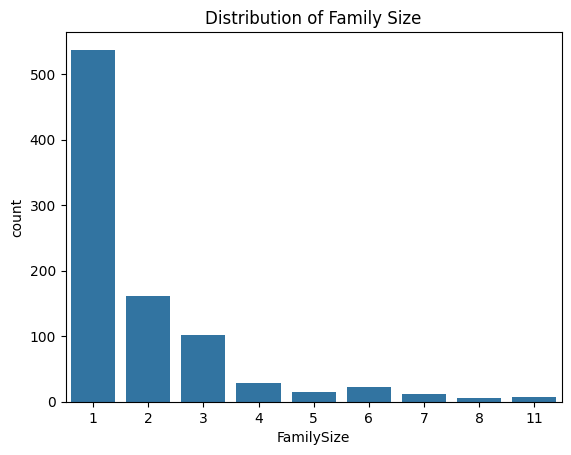

In [36]:
sns.countplot(x='FamilySize', data=df)
plt.title("Distribution of Family Size")
plt.show()

### IsAlone Feature

Passengers traveling alone may have different survival chances.

IsAlone = 1 if FamilySize == 1
IsAlone = 0 otherwise

In [37]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['FamilySize','IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


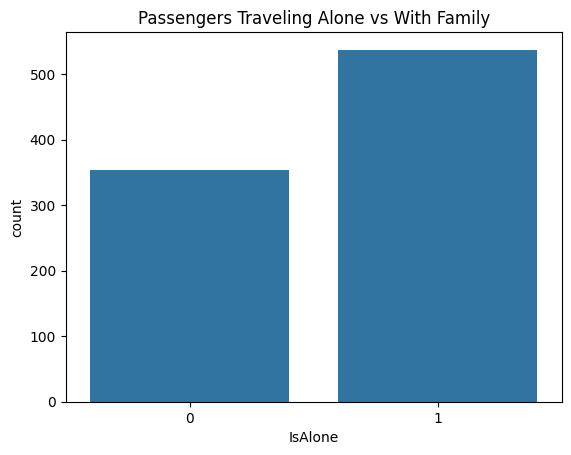

In [38]:
sns.countplot(x='IsAlone', data=df)
plt.title("Passengers Traveling Alone vs With Family")
plt.show()

### Title Extraction

Titles extracted from passenger names may reflect social status
and gender, which could influence survival probability.

Examples:
Mr, Mrs, Miss, Master

In [39]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Title'].value_counts()

<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_11132\99609571.py:1: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [34]:
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)

df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [41]:
rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']

df['Title'] = df['Title'].replace(rare_titles,'Rare')

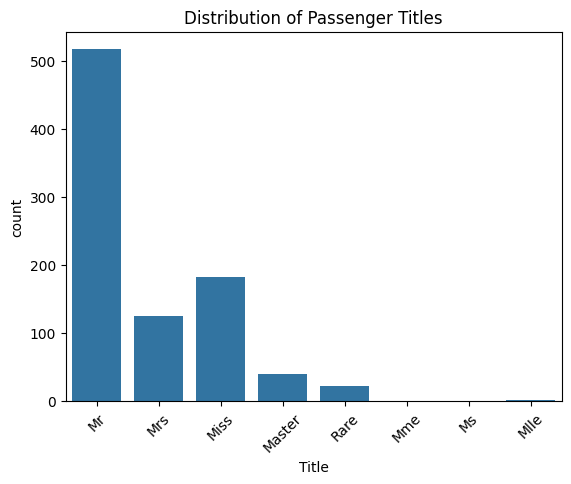

In [42]:
sns.countplot(x='Title', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Passenger Titles")
plt.show()

### Deck Extraction

Cabin numbers indicate the deck where passengers stayed.
The first letter of the Cabin value represents the deck.

In [43]:
df['Deck'] = df['Cabin'].str[0]

df[['Cabin','Deck']].head()

,Cabin,Deck
0,U,U
1,C85,C
2,U,U
3,C123,C
4,U,U


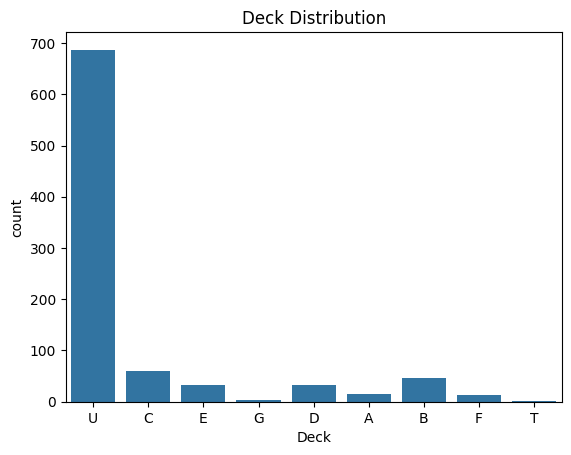

In [44]:
sns.countplot(x='Deck', data=df)
plt.title("Deck Distribution")
plt.show()

### Age Groups

Passengers are categorized into age groups:

Child: 0–12
Teen: 13–19
Adult: 20–59
Senior: 60+

In [45]:
def age_group(age):

    if age < 13:
        return "Child"
    elif age < 20:
        return "Teen"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

df['AgeGroup'] = df['Age'].apply(age_group)

df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


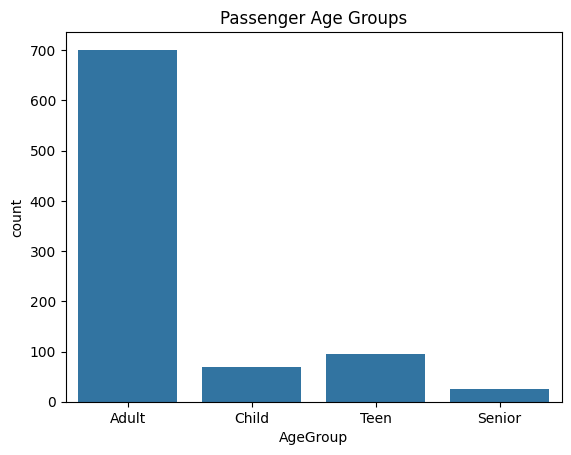

In [46]:
sns.countplot(x='AgeGroup', data=df)
plt.title("Passenger Age Groups")
plt.show()

### Fare Per Person

Ticket fare divided by family size provides a better representation
of individual ticket cost.

In [47]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

df[['Fare','FamilySize','FarePerPerson']].head()

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.6250
1,65.6344,2,32.8172
2,7.9250,1,7.9250
3,53.1000,2,26.5500
4,8.0500,1,8.0500


## Categorical Encoding

Machine learning algorithms require numerical input.
Categorical features are converted using one-hot encoding.

Features encoded:
- Sex
- Embarked
- Title
- Deck

In [49]:
cols_to_encode = [col for col in ['Sex','Embarked','Title','Deck'] if col in df.columns]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

### Interaction Features

Interaction features combine variables to capture relationships
between them.

In [50]:
df['Pclass_Fare'] = df['Pclass'] * df['Fare']

In [51]:
df['Age_Fare'] = df['Age'] * df['Fare']

## Feature Transformations

Some numerical variables such as Fare are highly skewed.
Log transformation helps normalize their distribution.

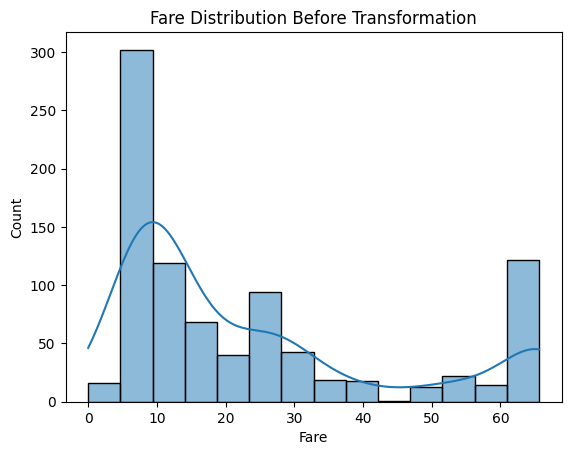

In [52]:
sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution Before Transformation")
plt.show()

In [53]:
df['Fare'] = np.log1p(df['Fare'])
df['Age'] = np.log1p(df['Age'])

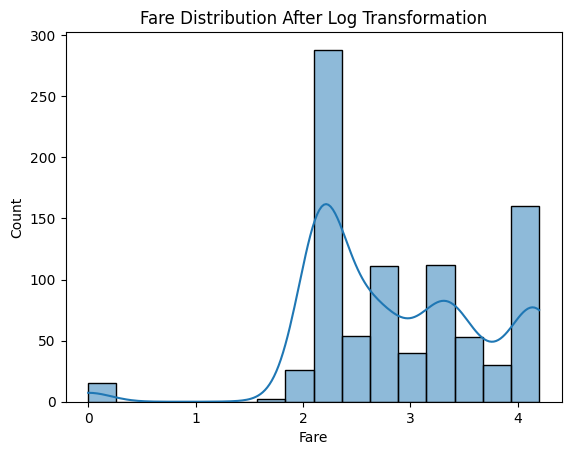

In [54]:
sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution After Log Transformation")
plt.show()

### Feature Scaling

Standardization ensures that features have similar scales,
which is important for distance-based models.

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age','Fare','FarePerPerson']] = scaler.fit_transform(
    df[['Age','Fare','FarePerPerson']]
)

### Summary of Engineered Features

The following features were created:

- FamilySize
- IsAlone
- Title
- Deck
- AgeGroup
- FarePerPerson
- Interaction features

Transformations applied:
- Log transformation for Age and Fare
- Standard scaling for numerical features

## Feature Selection

Feature selection identifies the most relevant variables for predicting
passenger survival. Removing irrelevant or redundant features helps:

- Reduce model complexity
- Improve model accuracy
- Reduce overfitting

Methods used:
1. Correlation analysis
2. Feature importance using Random Forest
3. Recursive Feature Elimination (RFE)

### Correlation Analysis

Correlation analysis helps detect highly correlated features which may
provide redundant information.

A heatmap is used to visualize relationships between variables.

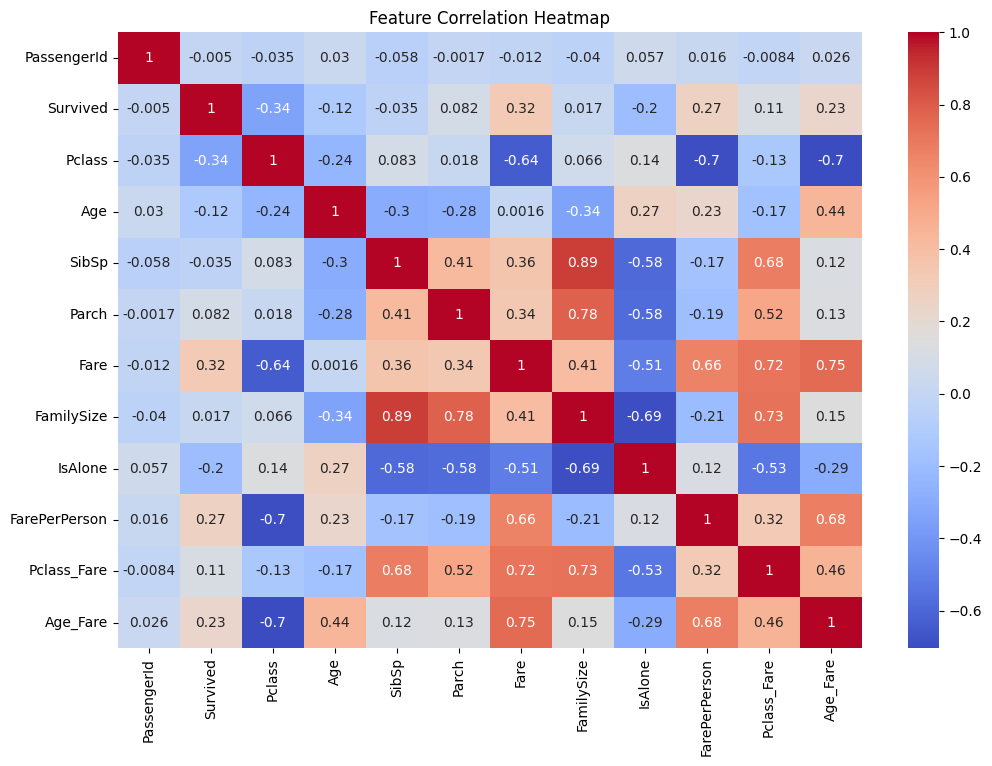

In [58]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation

From the correlation heatmap, we identify features that are highly
correlated with each other. Highly correlated features may provide
similar information to the model.

Examples of potential redundancy:
- FamilySize and IsAlone
- Fare and FarePerPerson

To avoid redundancy, one of the correlated features may be removed.

### Prepare Features and Target Variable

The dataset is split into:

X → input features  
y → target variable (Survived)

In [62]:
X = df.drop(columns=['Survived','PassengerId','Name','Ticket','Cabin','AgeGroup'], errors='ignore')

y = df['Survived']

In [63]:
X = X.select_dtypes(include=['number'])

### Feature Importance using Random Forest

Tree-based models like Random Forest can estimate the importance of each
feature in predicting survival.

In [64]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

importance.head(10)

Age_Fare         0.232339
Age              0.208729
Fare             0.144225
Pclass_Fare      0.134364
FarePerPerson    0.126549
Pclass           0.060719
FamilySize       0.031016
SibSp            0.024686
Parch            0.024489
IsAlone          0.012884
dtype: float64

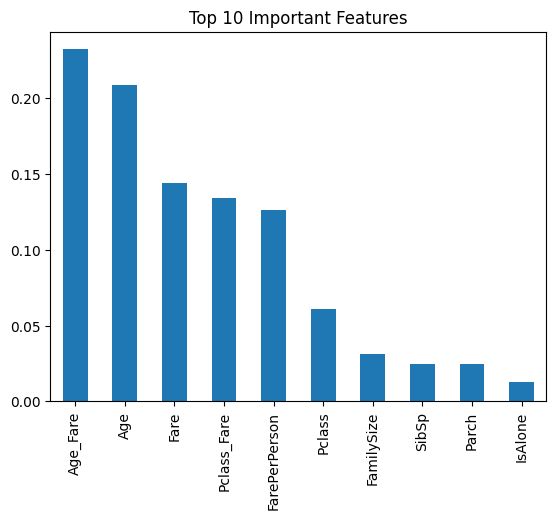

In [66]:
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

### Recursive Feature Elimination (RFE)

RFE selects the most important features by repeatedly training a model
and removing the least important features.

In [67]:
from sklearn.feature_selection import RFE

model = RandomForestClassifier(random_state=42)

rfe = RFE(model, n_features_to_select=10)

rfe.fit(X,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [68]:
selected_features = X.columns[rfe.support_]

selected_features

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone',
       'FarePerPerson', 'Pclass_Fare', 'Age_Fare'],
      dtype='str')

### Selected Features for Model

Based on feature importance and RFE, the following features were selected:

- Sex
- Pclass
- Fare
- Title
- Age
- FamilySize
- IsAlone
- Deck
- Embarked
- FarePerPerson

These features were selected because they show strong predictive power
for survival.

### Feature Selection Justification

Features kept:
- Sex → Strong predictor of survival
- Pclass → Indicates socioeconomic status
- Fare → Higher fare passengers had better survival
- Title → Captures gender and social status
- Age → Children had higher survival rates

Features removed:
- PassengerId → Only identifier
- Ticket → High cardinality and low predictive value
- Cabin → Mostly missing values
- Name → Already used to extract Title

## Conclusion

This project demonstrated how feature engineering and feature selection
can significantly improve predictive modeling. Features such as Sex,
Pclass, Age, and Fare showed strong influence on survival probability.